In [1]:
import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [2]:
!nvidia-smi

Fri Jul 10 11:19:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [42]:
import pickle
import numpy as np
import pandas as pd
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from torchvision.transforms import v2

import torchsummary

from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline

import random, numpy as np, os
import torch.optim as optim
from torchvision import models

import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)


In [5]:
!python --version
from importlib.metadata import version
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ version(b))

Python 3.12.13
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
tqdm version: 4.67.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
Pillow version: 11.3.0


In [6]:
DATA_MODES = ['train', 'val', 'test']
DEVICE = torch.device("cuda")

TRAIN_DIR = Path('./data/train/')
TEST_DIR = Path('./data/testset')

NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

RESCALE_SIZE = [224, 224]

# Загрузка данных

In [7]:
!gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1

Downloading...
From (original): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1
From (redirected): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1&confirm=t&uuid=ab836ba9-730e-4060-95ea-3327aa8f4cab
To: /kaggle/working/journey-springfield.zip
100%|█████████████████████████████████████████| 546M/546M [00:04<00:00, 110MB/s]


In [8]:
!unzip -q /kaggle/working/journey-springfield.zip -d data

In [9]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

In [10]:
# Кодировать имена персонажей в числовые метки класса и обратно будем при помощи LabelEncoder.
label_encoder = LabelEncoder()
train_val_labels = [path.parent.name for path in train_val_files]
label_encoder.fit(train_val_labels)

LabelEncoder()

In [11]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size=0.25, stratify=train_val_labels)

### Создаем Datasets и Dataloaders + Augmentstion 

In [12]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        self.files = sorted(files)
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            #v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
            v2.Resize(RESCALE_SIZE),
          ])
      else:
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)


In [13]:
train_dataset = SimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset(val_files, label_encoder, mode='val')

In [14]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {'train':train_loader, 'val': val_loader}

### Посмотрим персонажей

In [15]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

In [16]:
def show_images(n_rows, n_cols, dataset):
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), sharey=True, sharex=True)

  for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0, len(dataset)))
    im_val, label = dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(), label_encoder.inverse_transform([label])[0].split('_')))  
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x)
    fig_x.set_axis_off()
  return None

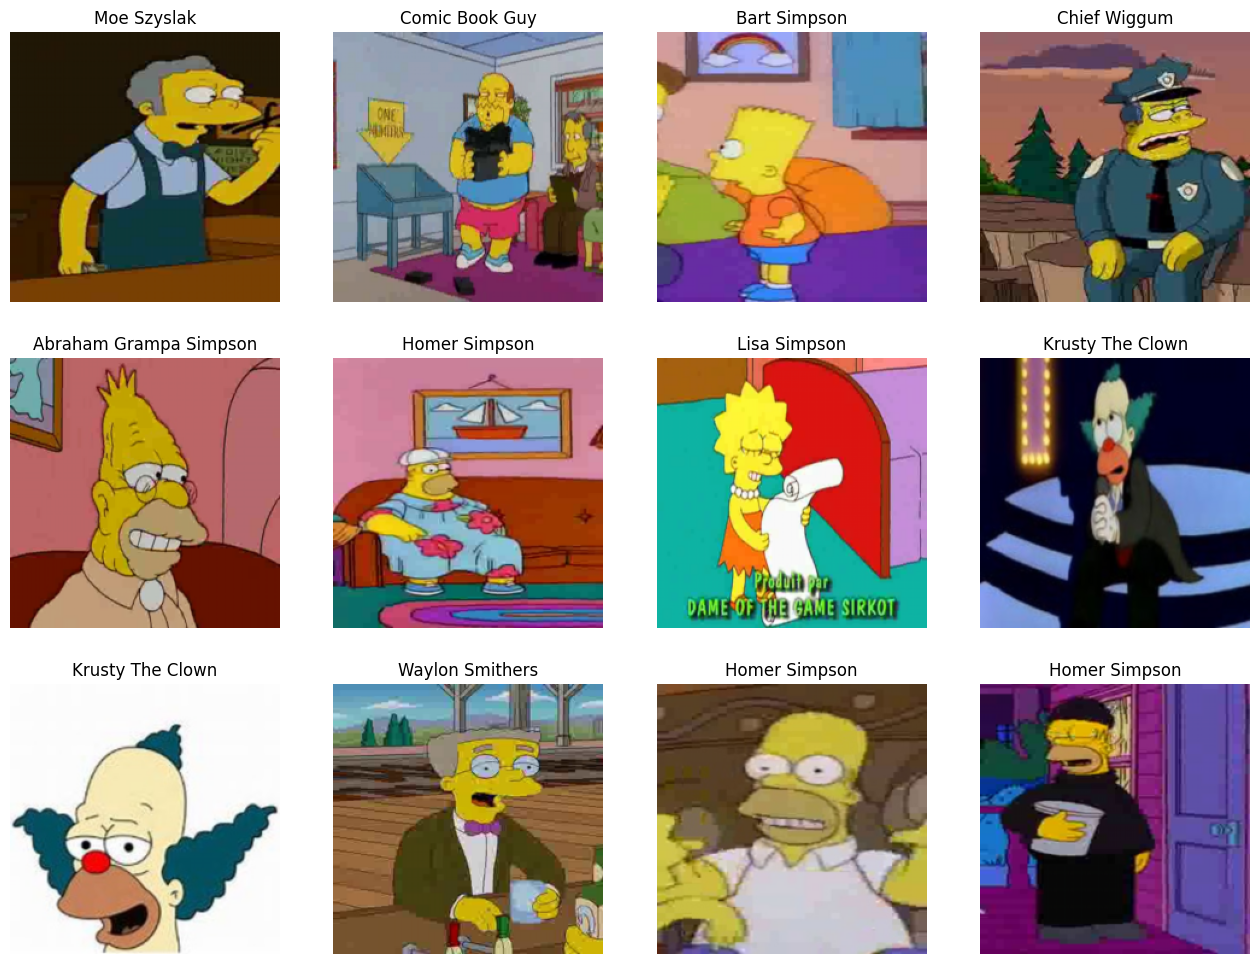

In [17]:
show_images(n_rows = 3, n_cols = 4, dataset = val_dataset)

# Функции для работы с моделью

In [53]:
from sklearn.metrics import f1_score

def count_f1_metrics(y, pred):
    return f1_score(y, pred, average='micro')

In [54]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outp = model(x_batch)
        loss = criterion(outp, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outp.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / len(loader), correct / total

In [55]:
def test_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outp = model(x_batch)
            loss = criterion(outp, y_batch)
            total_loss += loss.item()

            preds = outp.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / len(loader), correct / total


In [56]:
def all_epoch_cycle(model, loaders, optimizer, criterion, max_epochs, device):
    model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(model, loaders["train"], optimizer, criterion, device)
        test_loss, test_acc = test_one_epoch(model, loaders["val"], criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}")
        print(f"          Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")

    return history, max_epochs


In [57]:
def plot_metrics(history, max_epochs):
    epochs = range(1, max_epochs + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
    plt.plot(epochs, history['test_acc'], 'r-', label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Transfer Learning

In [40]:
SEED = 42
num_epochs = 12
lr_head = 1e-3
lr_backbone = 1e-4
weight_decay = 1e-4
model_path = "best_resnet50.pth"

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [43]:
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Fine tuning

In [62]:
num_classes = len(label_encoder.classes_)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

backbone_params = []
head_params = []
for name, p in model.named_parameters():
    if name.startswith("fc."):
        head_params.append(p)
    else:
        backbone_params.append(p)

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-5},
    {"params": head_params, "lr": 1e-3}
], weight_decay=1e-4)

num_epochs = 10
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = torch.amp.GradScaler('cuda')

history, max_epochs = all_epoch_cycle(
    model, 
    loaders,
    optimizer, 
    criterion, 
    max_epochs=10, 
    device=device
)

Epoch 1: Train Loss = 1.0646, Test Loss = 0.3278
          Train Acc = 0.7499, Test Acc = 0.9186
Epoch 2: Train Loss = 0.1902, Test Loss = 0.2127
          Train Acc = 0.9551, Test Acc = 0.9469
Epoch 3: Train Loss = 0.0651, Test Loss = 0.1883
          Train Acc = 0.9857, Test Acc = 0.9528
Epoch 4: Train Loss = 0.0219, Test Loss = 0.1754
          Train Acc = 0.9971, Test Acc = 0.9559
Epoch 5: Train Loss = 0.0099, Test Loss = 0.1656
          Train Acc = 0.9992, Test Acc = 0.9585
Epoch 6: Train Loss = 0.0059, Test Loss = 0.1667
          Train Acc = 0.9994, Test Acc = 0.9593
Epoch 7: Train Loss = 0.0036, Test Loss = 0.1664
          Train Acc = 0.9996, Test Acc = 0.9593
Epoch 8: Train Loss = 0.0024, Test Loss = 0.1667
          Train Acc = 0.9999, Test Acc = 0.9606
Epoch 9: Train Loss = 0.0019, Test Loss = 0.1710
          Train Acc = 0.9999, Test Acc = 0.9610
Epoch 10: Train Loss = 0.0017, Test Loss = 0.1694
          Train Acc = 0.9997, Test Acc = 0.9612


### Посмотрим на submission

In [70]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

In [71]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(DEVICE).int()
    print("Test mode...")
    for inputs in tqdm_notebook(loader):
        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)

            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)
    return all_predictions.cpu()

In [72]:
predicted_numeric_labels = predict(model, test_loader)
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(1)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

,Id,Expected
0,img0.jpg,nelson_muntz


In [73]:
my_submission.to_csv('fine_tuning.csv', index=False)